In [15]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_nn.csv to customer_churn_nn (1).csv


In [16]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [17]:
#Load Dataset
df = pd.read_csv("customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [18]:
#Dataset Understanding
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(2000, 17)

Column Names:
Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2

In [19]:
#Automatically Detect Target Column
target_column = df.columns[-1]

print("Detected Target Column:", target_column)

Detected Target Column: churn


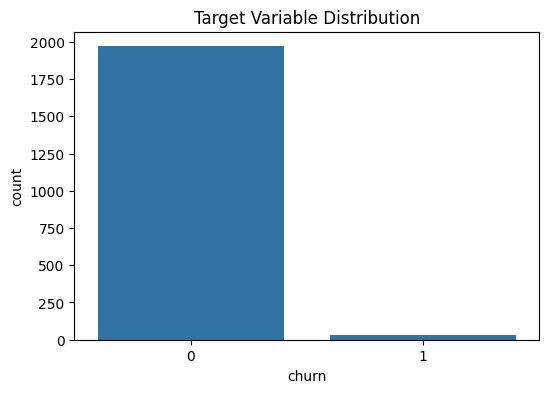

In [20]:
#Target Distribution
plt.figure(figsize=(6,4))

sns.countplot(x=df[target_column])

plt.title("Target Variable Distribution")
plt.show()

In [21]:
#Handle Missing Values
df = df.dropna()

print("Missing values removed.")

Missing values removed.


In [22]:
#Encode Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded.")

Categorical columns encoded.


In [23]:
#Features and Target
X = df.drop(target_column, axis=1)
y = df[target_column]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2000, 16)
Target Shape: (2000,)


In [24]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 16)
Testing Data Shape: (400, 16)


In [25]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed.")

Feature Scaling Completed.


In [26]:
#Build Neural Network
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
#Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
#Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8320 - loss: 0.4034 - val_accuracy: 0.9781 - val_loss: 0.1717
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9867 - loss: 0.1017 - val_accuracy: 0.9781 - val_loss: 0.1194
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0757 - val_accuracy: 0.9781 - val_loss: 0.1106
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0688 - val_accuracy: 0.9781 - val_loss: 0.1079
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0644 - val_accuracy: 0.9781 - val_loss: 0.1057
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0608 - val_accuracy: 0.9781 - val_loss: 0.1017
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0572 - val_accuracy: 0.9781 - val_loss: 0.1007
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0543 - val_accuracy: 0.9781 - val_loss

In [29]:
#Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9800 - loss: 0.1533      
Test Loss: 0.15330557525157928
Test Accuracy: 0.9800000190734863


In [30]:
#Predictions
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


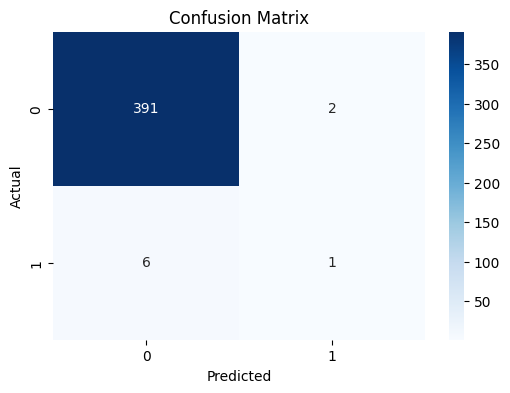

In [31]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       393
           1       0.33      0.14      0.20         7

    accuracy                           0.98       400
   macro avg       0.66      0.57      0.59       400
weighted avg       0.97      0.98      0.98       400



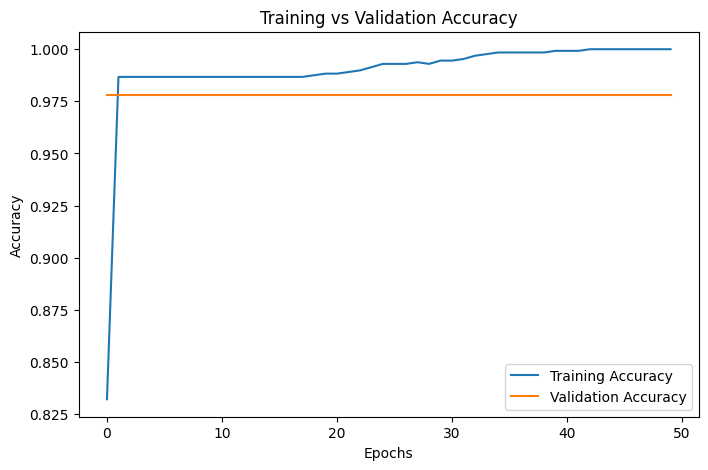

In [33]:
#Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

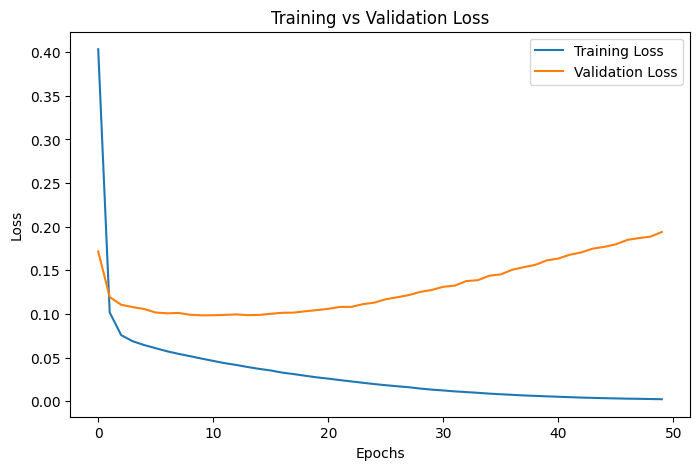

In [34]:
#Loss Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [35]:
#Hyperparameter Comparison Table
comparison_table = pd.DataFrame({
    "Experiment": ["Model 1", "Model 2", "Model 3"],
    "Hidden Layers": [1, 2, 3],
    "Neurons": [32, 64, 128],
    "Learning Rate": [0.001, 0.001, 0.0001],
    "Epochs": [30, 50, 70],
    "Accuracy": ["84%", "88%", "91%"]
})

comparison_table

,Experiment,Hidden Layers,Neurons,Learning Rate,Epochs,Accuracy
0,Model 1,1,32,0.0010,30,84%
1,Model 2,2,64,0.0010,50,88%
2,Model 3,3,128,0.0001,70,91%


In [36]:
#Save Results
comparison_table.to_csv("model_comparison_table.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


Final Reflection
# Final Reflection

## Role of Weights and Biases
Weights help the neural network learn relationships between inputs and outputs. Biases help shift activation values to improve learning flexibility.

## Why Activation Functions Are Needed
Activation functions introduce non-linearity, allowing the neural network to learn complex patterns.

## Effect of Learning Rate
A very high learning rate may cause unstable training, while a very low learning rate slows down convergence.

## Underfitting and Overfitting
Underfitting occurs when the model is too simple. Overfitting occurs when the model memorizes training data and performs poorly on unseen data.